<a href="https://colab.research.google.com/github/Raijeku/quantum-eigengame/blob/main/EigenGame_quantum_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installs and imports

In [ ]:
!pip install pennylane
!pip install pennylane-qulacs["cpu"]
!pip install pyscf
!pip install qiskit-nature

In [ ]:
import autograd.numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import qaoa
from pennylane import numpy as np
from scipy.linalg import expm, sqrtm, eigh
import networkx as nx
from jax import grad
import jax.numpy as jnp
import numpy
from tqdm import tqdm
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.legend_handler import HandlerTuple

np.random.seed(0)

# Google drive

In [ ]:
import os
from datetime import date

today = str(date.today())

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

parent_dir = "/content/drive/My Drive/QuantumGame"

if not os.path.isdir(parent_dir):
  os.makedirs(parent_dir)

current_dir = f"/content/drive/My Drive/QuantumGame/{today}"

if not os.path.isdir(current_dir):
  os.makedirs(current_dir)

current_dir += '/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# $U1(\theta)$ ansatz gradient verification

In [ ]:
import jax.numpy as jnp

## 1 qubit at depth 1

In [ ]:
Z = np.array([[1, 0], [0, -1]])
s = np.ones(2)
s /= np.linalg.norm(s)
Z, s

def U1(theta):
  return jnp.array([[1, 0], [0, jnp.exp(theta*1j)]])

def circuit_U1(theta):
  return jnp.conjugate(s @ U1(theta)).T @ Z @ U1(theta) @ s

def A(theta_k):
  return jnp.array([[0, 0], [0, 1j*jnp.exp(1j*theta_k)]])

def grad_U1(theta):
  return 2 * np.conjugate(s @ U1(theta)).T @ Z @ A(theta) @ s

print(U1(0))
print(circuit_U1(0))

[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
0j


In [ ]:
theta = 0. + 0j

grad_func = grad(circuit_U1, holomorphic=True)(theta)
grad_func

Array(0.-0.99999994j, dtype=complex64, weak_type=True)

In [ ]:
grad_U1(theta)

Array(0.-0.99999994j, dtype=complex64)

## q qubit at depth 1

In [ ]:
qubits = 3
Z = np.array([[1, 0], [0, -1]])
for i in range(qubits-1):
  Z = np.kron(Z, np.array([[1, 0], [0, -1]]) )
s = np.ones(2**qubits)
s /= np.linalg.norm(s)
print(Z, s)

def U1(theta):
  U1 = jnp.array([[1, 0], [0, jnp.exp(theta[0]*1j)]])
  for i in range(1, qubits):
    U1 = jnp.kron(U1, jnp.array([[1, 0], [0, jnp.exp(theta[i]*1j)]]))
  return U1

def circuit_U1(theta):
  return jnp.conjugate(s @ U1(theta)).T @ Z @ U1(theta) @ s

def A(theta_k):
  return jnp.array([[0, 0], [0, 1j*jnp.exp(1j*theta_k)]])

def grad_U1(theta):

  grad_inner = []

  grad_inner_0 = A(theta[0])
  for i in range(1, qubits):
    grad_inner_0 = jnp.kron(grad_inner_0, jnp.array([[1, 0], [0, jnp.exp(theta[i]*1j)]]))
  grad_inner.append(grad_inner_0)

  U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0]*1j)]])
  for i in range(1, len(theta)):
    grad = U1_0
    for j in range(1, i):
      grad = jnp.kron(grad, np.array([[1, 0], [0, jnp.exp(theta[j]*1j)]]))
    grad = jnp.kron(grad, A(theta[i]))
    for j in range(i+1, qubits):
      grad = jnp.kron(grad, np.array([[1, 0], [0, jnp.exp(theta[j]*1j)]]))
    grad_inner.append(grad)

  return jnp.array([2 * jnp.conjugate(s @ U1(theta)).T @ Z @ grad_i @ s for grad_i in grad_inner])

print(U1(np.array([0, 0, 0])))
print(circuit_U1(np.array([0, 0, 0])))

[[ 1  0  0  0  0  0  0  0]
 [ 0 -1  0  0  0  0  0  0]
 [ 0  0 -1  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0]
 [ 0  0  0  0 -1  0  0  0]
 [ 0  0  0  0  0  1  0  0]
 [ 0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0 -1]] [0.35355339 0.35355339 0.35355339 0.35355339 0.35355339 0.35355339
 0.35355339 0.35355339]
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]
0j


In [ ]:
theta = np.ones(qubits) + 1j*np.zeros(qubits)

grad_func = grad(circuit_U1, holomorphic=True)(theta)
grad_func

Array([ 5.7372224e-10+1.6650121e-08j,  5.7372224e-10+1.6650121e-08j,
       -1.7026657e-08+2.8641157e-08j], dtype=complex64)

In [ ]:
grad_U1(theta)

Array([ 5.8855354e-10+1.4901161e-08j,  5.8855354e-10+1.4901161e-08j,
       -3.0994556e-09+1.4901161e-08j], dtype=complex64)

## 1 qubit at depth p

In [ ]:
qubits = 1
depth = 3
Z = np.array([[1, 0], [0, -1]])
s = np.ones(2**qubits)
s /= np.linalg.norm(s)
print(Z, s)

def U1(theta):
  U1 = jnp.array([[1, 0], [0, jnp.exp(theta[0]*1j)]])
  for i in range(1, depth):
    U1 = U1 @ jnp.array([[1, 0], [0, jnp.exp(theta[i]*1j)]])
  return U1

def circuit_U1(theta):
  return jnp.conjugate(s @ U1(theta)).T @ Z @ U1(theta) @ s

def A(theta_k):
  return jnp.array([[0, 0], [0, 1j*jnp.exp(1j*theta_k)]])

def grad_U1(theta):

  grad_inner = []

  grad_inner_0 = A(theta[0])
  for i in range(1, depth):
    grad_inner_0 = grad_inner_0 @ jnp.array([[1, 0], [0, jnp.exp(theta[i]*1j)]])
  grad_inner.append(grad_inner_0)

  U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0]*1j)]])
  for i in range(1, len(theta)):
    grad = U1_0
    for j in range(1, i):
      grad = grad @ np.array([[1, 0], [0, jnp.exp(theta[j]*1j)]])
    grad = grad @ A(theta[i])
    for j in range(i+1, depth):
      grad = grad @ np.array([[1, 0], [0, jnp.exp(theta[j]*1j)]])
    grad_inner.append(grad)

  return jnp.array([2 * jnp.conjugate(s @ U1(theta)).T @ Z @ grad_i @ s for grad_i in grad_inner])

print(U1(np.array([0, 0, 0])))
print(circuit_U1(np.array([0, 0, 0])))

[[ 1  0]
 [ 0 -1]] [0.70710678 0.70710678]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
0j


In [ ]:
theta = np.ones(depth) + 1j*np.zeros(depth)

grad_func = grad(circuit_U1, holomorphic=True)(theta)
grad_func

Array([ 4.6761670e-09-0.99999976j,  4.6761670e-09-0.99999976j,
       -2.5126155e-08-0.99999976j], dtype=complex64)

In [ ]:
grad_U1(theta)

Array([-4.3692885e-09-0.9999997j, -4.3692885e-09-0.9999997j,
       -4.3692885e-09-0.9999997j], dtype=complex64)

## q qubit at depth p

In [ ]:
qubits = 3
depth = 3
Z = np.array([[1, 0], [0, -1]])
for i in range(qubits-1):
  Z = np.kron(Z, np.array([[1, 0], [0, -1]]) )
s = np.ones(2**qubits)
s /= np.linalg.norm(s)
print(Z, s)

def U1(theta):
  U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0, 0]*1j)]])
  U1 = U1_0
  for i in range(1, qubits):
    U1 = jnp.kron(U1, jnp.array([[1, 0], [0, jnp.exp(theta[0, i]*1j)]]))
  for i in range(1, depth):
    U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
    for j in range(1, qubits):
      U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
    U1 = U1 @ U1_i
  return U1

def circuit_U1(theta):
  return jnp.conjugate(s @ U1(theta)).T @ Z @ U1(theta) @ s

def A(theta_l_k):
  return jnp.array([[0, 0], [0, 1j*jnp.exp(1j*theta_l_k)]])

def grad_U1(theta):

  grad_inner = []

  grad_inner_row = []

  # depth 0 qubit 0
  grad_inner_0 = A(theta[0, 0])
  for i in range(1, qubits):
    grad_inner_0 = jnp.kron(grad_inner_0, jnp.array([[1, 0], [0, jnp.exp(theta[0, i]*1j)]]))
  for i in range(1, depth):
    grad_inner_0_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
    for j in range(1, qubits):
      grad_inner_0_i = jnp.kron(grad_inner_0_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
    grad_inner_0 = grad_inner_0 @ grad_inner_0_i
  grad_inner_row.append(grad_inner_0)

  # depth 0 qubit i>0
  for i in range(1, qubits):
    U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0, 0]*1j)]])
    grad = U1_0
    for j in range(1, i):
      grad = jnp.kron(grad, jnp.array([[1, 0], [0, jnp.exp(theta[0, j]*1j)]]))
    grad = jnp.kron(grad, A(theta[0, i]))
    for j in range(i+1, qubits):
      grad = jnp.kron(grad, jnp.array([[1, 0], [0, jnp.exp(theta[0, j]*1j)]]))
    for i in range(1, depth):
      U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
      for j in range(1, qubits):
        U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
      grad = grad @ U1_i
    grad_inner_row.append(grad)

  grad_inner.append(grad_inner_row)

  # depth p>0 qubit q
  for l in range(1, depth):
    grad_inner_row = []

    # depth p>0 qubit 0
    U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0, 0]*1j)]])
    for i in range(1, qubits):
      U1_0 = jnp.kron(U1_0, jnp.array([[1, 0], [0, jnp.exp(theta[0, i]*1j)]]))
    grad = U1_0
    for i in range(1, l):
      U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
      for j in range(1, qubits):
        U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
      grad = grad @ U1_i

    U1_l = A(theta[l, 0])
    for i in range(1, qubits):
      U1_l = jnp.kron(U1_l, jnp.array([[1, 0], [0, jnp.exp(theta[l, i]*1j)]]))
    grad = grad @ U1_l

    for i in range(l+1, depth):
      U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
      for j in range(1, qubits):
        U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
      grad = grad @ U1_i
    grad_inner_row.append(grad)

    # depth p>0 qubit q>0
    for k in range(1, qubits):

      U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0, 0]*1j)]])
      for i in range(1, qubits):
        U1_0 = jnp.kron(U1_0, jnp.array([[1, 0], [0, jnp.exp(theta[0, i]*1j)]]))
      grad = U1_0

      for i in range(1, l):
        U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
        for j in range(1, qubits):
          U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
        grad = grad @ U1_i

      U1_l = jnp.array([[1, 0], [0, jnp.exp(theta[l, 0]*1j)]])
      for i in range(1, k):
        U1_l = jnp.kron(U1_l, jnp.array([[1, 0], [0, jnp.exp(theta[l, i]*1j)]]))
      U1_l = jnp.kron(U1_l, A(theta[l, k]))
      for i in range(k+1, qubits):
        U1_l = jnp.kron(U1_l, jnp.array([[1, 0], [0, jnp.exp(theta[l, i]*1j)]]))
      grad = grad @ U1_l

      for i in range(l+1, depth):
        U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
        for j in range(1, qubits):
          U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
        grad = grad @ U1_i
      grad_inner_row.append(grad)

    grad_inner.append(grad_inner_row)

  return jnp.array([[2 * jnp.conjugate(s @ U1(theta)).T @ Z @ grad_i_j @ s for grad_i_j in grad_inner_i] for grad_inner_i in grad_inner ])

print(U1(np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])))
print(circuit_U1(np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])))

[[ 1  0  0  0  0  0  0  0]
 [ 0 -1  0  0  0  0  0  0]
 [ 0  0 -1  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0]
 [ 0  0  0  0 -1  0  0  0]
 [ 0  0  0  0  0  1  0  0]
 [ 0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0 -1]] [0.35355339 0.35355339 0.35355339 0.35355339 0.35355339 0.35355339
 0.35355339 0.35355339]
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]
0j


In [ ]:
theta = np.zeros((depth, qubits)) + 1j*np.ones((depth, qubits))

grad_func = grad(circuit_U1, holomorphic=True)(theta)
grad_func

Array([[0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j],
       [0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j],
       [0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j]], dtype=complex64)

In [ ]:
grad_U1(theta)

Array([[0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j],
       [0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j],
       [0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j]], dtype=complex64)

# QuantumGame vs VQD

## Functions and setup

In [ ]:
def generate_pauli_string(qubits, terms=1):

  basis = ['X', 'Y', 'Z', 'I']

  pauli_list = []
  coeffs = numpy.random.rand(terms)
  for term in range(terms):
    pauli_list.append(''.join(numpy.random.choice(basis, size=qubits)))

  return pauli_list, coeffs

def term_to_pauli(pauli_term):
  Z = numpy.array([[1, 0], [0, -1]])
  X = numpy.array([[0, 1], [1, 0]])
  Y = numpy.array([[0, -1j], [1j, 0]])
  I = numpy.eye(2)

  match pauli_term:
      case 'X':
        return X
      case 'Y':
        return Y
      case 'Z':
        return Z
      case 'I':
        return I

def pauli_to_matrices(pauli_list):

  matrix_list = []
  for pauli_string in pauli_list:
    matrix = term_to_pauli(pauli_string[0])
    for pauli_term in pauli_string[1:]:
      matrix = numpy.kron(matrix, term_to_pauli(pauli_term))
    matrix_list.append(matrix)
  return matrix_list

def full_matrix(paulis, coeffs):
  matrix = numpy.zeros_like(paulis[0]).astype(complex)
  for i in range(len(coeffs)):
    matrix += coeffs[i]*paulis[i]

  return matrix

def pauli_to_gate(pauli_string, start_index=0):
  terms = list(pauli_string)
  term = terms[0]
  if term=='X':
      gates = qml.PauliX(start_index)
  elif term=='Y':
    gates = qml.PauliY(start_index)
  elif term=='Z':
    gates = qml.PauliZ(start_index)
  else:
    gates = qml.Identity(start_index)
  for i, term in enumerate(terms[1:]):
    if term=='X':
      gates = gates @ qml.PauliX(start_index+i+1)
    elif term=='Y':
      gates = gates @ qml.PauliY(start_index+i+1)
    elif term=='Z':
      gates = gates @ qml.PauliZ(start_index+i+1)
    else:
      gates = gates @ qml.Identity(start_index+i+1)
  return gates

pauli_list, coeffs = generate_pauli_string(3, terms=10)
print(pauli_list, coeffs)

matrices = pauli_to_matrices(pauli_list)
print(matrices)

['ZII', 'ZXY', 'YYY', 'XYX', 'IXI', 'YZI', 'IXZ', 'IXY', 'IYI', 'IZI'] [0.5488135  0.71518937 0.60276338 0.54488318 0.4236548  0.64589411
 0.43758721 0.891773   0.96366276 0.38344152]
[array([[ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -1., -0., -0., -0.],
       [ 0.,  0.,  0.,  0., -0., -1., -0., -0.],
       [ 0.,  0.,  0.,  0., -0., -0., -1., -0.],
       [ 0.,  0.,  0.,  0., -0., -0., -0., -1.]]), array([[ 0.+0.j,  0.-0.j,  0.+0.j,  0.-1.j,  0.+0.j,  0.-0.j,  0.+0.j,
         0.-0.j],
       [ 0.+0.j,  0.+0.j,  0.+1.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.-1.j,  0.+0.j,  0.-0.j,  0.+0.j,  0.-0.j,  0.+0.j,
         0.-0.j],
       [ 0.+1.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.-0.j,  0.+0.j,  0.-0.j,  0.+0.j,  0.-0.j, -0.

**Experiment setup**

We initialize the H2 molecule Hamiltonian by using the ParityMapper to use a two-qubit version of the molecule Hamiltonian.



In [ ]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper

driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)

problem = driver.run()
hamiltonian = problem.hamiltonian.second_q_op()
mapper = ParityMapper(num_particles=problem.num_particles)
qubit_op = mapper.map(hamiltonian)

pauli_list = []
coeffs = []
for pauli, coeff in sorted(qubit_op.label_iter()):
    print(f"{coeff.real:+.8f} * {pauli}")
    pauli_list.append(pauli)
    coeffs.append(-coeff.real)

-1.05237325 * II
+0.39793742 * IZ
+0.18093120 * XX
-0.39793742 * ZI
-0.01128010 * ZZ


In [ ]:
qubits = 2
dim = 2**qubits
#pauli_list, coeffs = generate_pauli_string(qubits, terms=10)
pauli_gates = [pauli_to_gate(pauli_str) for pauli_str in pauli_list]
pauli_gatesh = [pauli_to_gate(pauli_str, start_index=1) for pauli_str in pauli_list]
print(pauli_list)
print(pauli_gates)
print(pauli_gatesh)
matrices = pauli_to_matrices(pauli_list)
matrix = full_matrix(matrices, coeffs)
print(np.linalg.eigvalsh(matrix))
L = np.linalg.norm(matrix)
alpha = 1/(2*L)

['II', 'IZ', 'XX', 'ZI', 'ZZ']
[I(0) @ I(1), I(0) @ Z(1), X(0) @ X(1), Z(0) @ I(1), Z(0) @ Z(1)]
[I(1) @ I(2), I(1) @ Z(2), X(1) @ X(2), Z(1) @ I(2), Z(1) @ Z(2)]
[0.22491125 0.88272215 1.24458455 1.85727503]


## Exact eigenvalues

We calculate the exact eigenvalues to use as a baseline for the excited states calculated in the experiments that follow.

In [ ]:
exact_eigvals = sorted(np.linalg.eigvalsh(matrix), reverse=True)
data = {
    'exact_eigvals': exact_eigvals
}
file = open(current_dir + 'exact.pkl', 'wb')
pickle.dump(data, file)
file.close()

exact_eigvals

[tensor(1.85727503, requires_grad=True),
 tensor(1.24458455, requires_grad=True),
 tensor(0.88272215, requires_grad=True),
 tensor(0.22491125, requires_grad=True)]

## QuantumGame noiseless experiment

Here we set the functions and perform the experiments for a noiseless exact statevector simulation of QuantumGame.

In [ ]:
import warnings
from numpy.exceptions import ComplexWarning
warnings.filterwarnings("ignore", category=ComplexWarning)
from functools import partial

def quantum_eigengame(pauli_gates, pauli_gatesh, coeffs, dim, n_eigs=1, tol=1e-5, dev_name='default.qubit', optimizer=qml.AdagradOptimizer(stepsize=0.2), max_steps=100, layers=6, params_layer=5, shots=None):
  assert n_eigs <= dim, "n_eigs greater than the maximum number of eigenvalues"

  qubits = int(numpy.ceil(np.log2(dim)))
  wires = [i for i in range(qubits)]
  dev = qml.device(dev_name, wires=wires, shots=shots)

  qubitsh = qubits + 1
  wiresh = [i for i in range(qubitsh)]
  devh = qml.device(dev_name, wires=wiresh, shots=shots)

  def ansatz(params):
    qml.RandomLayers(params, wires=wires)

  def circuit_vqe(params):
      for w in wires:
        qml.Hadamard(wires=w)
      ansatz(params)

  @qml.compile
  @qml.qnode(dev, diff_method="adjoint")
  def cost_function_vqe(params, M):
      circuit_vqe(params)
      return qml.expval(M)
      #return qml.expval(qml.Hermitian(M, wires=wires))

  @qml.compile
  @qml.qnode(devh, diff_method="parameter-shift")
  def hadamard_test_real(params_a, params_b, pauli):

    # Layer for initial state
    for i in range(1, qubitsh):
      qml.Hadamard(i)

    # Hadamard test
    qml.Hadamard(0)
    qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))
    qml.ControlledQubitUnitary(qml.adjoint(qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))), 0)
    qml.ControlledQubitUnitary(qml.RandomLayers(weights=params_b, wires=range(1, qubitsh)), 0)
    qml.Hadamard(0)

    return qml.expval(qml.Z(0) @ pauli)
    #return qml.expval(qml.Hermitian(numpy.kron(Z, pauli), wires=range(qubitsh)))

  @qml.compile
  @qml.qnode(devh, diff_method="parameter-shift")
  def hadamard_test_imag(params_a, params_b, pauli):

    # Layer for initial state
    for i in range(1, qubitsh):
      qml.Hadamard(i)

    # Hadamard test
    qml.Hadamard(0)
    qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))
    qml.ControlledQubitUnitary(qml.adjoint(qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))), 0)
    qml.ControlledQubitUnitary(qml.RandomLayers(weights=params_b, wires=range(1, qubitsh)), 0)
    qml.S(0)
    qml.Hadamard(0)

    return qml.expval(qml.Z(0) @ pauli)
    #return qml.expval(qml.Hermitian(numpy.kron(Z, pauli), wires=range(qubitsh)))

  def hadamard_test(params_a, params_b, pauli):
    return hadamard_test_real(params_a, params_b, pauli) + 1j*hadamard_test_imag(params_a, params_b, pauli)

  def hadamard_test_sum(params, paulis, coeffs, j):
    pauli_combination = -paulis[0]*coeffs[0]
    for i in range(1, len(coeffs)):
        pauli_combination -= paulis[i]*coeffs[i]
    res = hadamard_test(params, params_vec[j], pauli_combination)
    return res

  def cost_function_vqe_sum(params, paulis, coeffs):
    pauli_combination = -paulis[0]*coeffs[0]
    for i in range(1, len(coeffs)):
      pauli_combination -= paulis[i]*coeffs[i]
    res = cost_function_vqe(params, pauli_combination)
    return res

  def cost_function_sum(params, paulis, paulish, coeffs):
    sum = cost_function_vqe_sum(params, paulis=paulis, coeffs=coeffs)
    for j in range(k):
      sum -= np.abs(hadamard_test_sum(params, paulish, coeffs, j))**2/eigenvalues[j]
    return sum

  k=0
  params_vec = []
  eigenvalues = []

  params = np.random.rand(layers, params_layer)

  costs_vec = []
  costs = []
  steps = []
  penalties = 0
  pbar = tqdm(range(max_steps))
  for i in pbar:
      #grad, cost = optimizer.compute_grad(cost_function_vqe_sum, params, paulis=pauli_gates, coeffs=coeffs)
      #params = optimizer.apply_grad(grad, params)
      params, cost = optimizer.step_and_cost(cost_function_vqe_sum, params, paulis=pauli_gates, coeffs=coeffs)
      grad = qml.grad(cost_function_vqe_sum)(params, paulis=pauli_gates, coeffs=coeffs)
      costs.append(-cost)
      rewards = cost
      pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
      if i > 1 and np.linalg.norm(grad) <= tol:
        steps.append(i+1)
        break
  if np.linalg.norm(grad) > tol:
      steps.append(max_steps)
  eigenvalues.append(cost)
  params_vec.append(params)
  costs_vec.append(costs)

  k += 1

  while k < n_eigs:
    params = np.random.rand(layers, params_layer)

    costs = []
    pbar = tqdm(range(max_steps))
    for i in pbar:
        #grad, cost = optimizer.compute_grad(cost_function_sum, params, paulis=pauli_gates, paulish=pauli_gatesh, coeffs=coeffs)
        #params = optimizer.apply_grad(grad, params)
        params, cost = optimizer.step_and_cost(cost_function_sum, params, paulis=pauli_gates, paulish=pauli_gatesh, coeffs=coeffs)
        grad = qml.grad(cost_function_sum)(params, paulis=pauli_gates, paulish=pauli_gatesh, coeffs=coeffs)
        costs.append(-cost)
        rewards = cost_function_vqe_sum(params, pauli_gates, coeffs)
        penalties = cost - rewards
        pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
        if i > 1 and np.linalg.norm(grad) <= tol:
          steps.append(i+1)
          break
    if np.linalg.norm(grad) > tol:
      steps.append(max_steps)

    eigenvalues.append(cost)
    params_vec.append(params)
    costs_vec.append(costs)
    k += 1

  return eigenvalues, params_vec, costs_vec, steps

eigenvalues, params_vec, costs_vec, steps_vec = quantum_eigengame(pauli_gates, pauli_gatesh, coeffs, dim, n_eigs=4, tol=1e-2, dev_name='lightning.qubit', optimizer=qml.GradientDescentOptimizer(stepsize=alpha), max_steps=500, layers=3, params_layer=3, shots=None)

Iteration 124, Cost: 1.8568, Rewards: 1.8568, Penalties: 0.0000, Gradient norm: 0.0099:  25%|██▍       | 123/500 [00:05<00:17, 21.11it/s]
Iteration 89, Cost: 1.2443, Rewards: 1.2443, Penalties: -0.0000, Gradient norm: 0.0096:  18%|█▊        | 88/500 [04:47<22:26,  3.27s/it]
Iteration 59, Cost: 0.8823, Rewards: 0.8827, Penalties: -0.0004, Gradient norm: 0.0098:  12%|█▏        | 58/500 [06:15<47:39,  6.47s/it]
Iteration 174, Cost: 0.2239, Rewards: 0.2339, Penalties: -0.0100, Gradient norm: 0.0099:  35%|███▍      | 173/500 [27:49<52:36,  9.65s/it]


In [ ]:
data = {
    'eigenvalues': eigenvalues,
    'params_vec': params_vec,
    'costs_vec': costs_vec,
    'steps_vec': steps_vec
}
file = open(current_dir + 'quantumgame_noiseless.pkl', 'wb')
pickle.dump(data, file)
file.close()

In [ ]:
file = open(current_dir + 'quantumgame_noiseless.pkl', 'rb')
data = pickle.load(file)
file.close()

eigenvalues = data['eigenvalues']
params_vec = data['params_vec']
costs_vec = data['costs_vec']
steps_vec = data['steps_vec']

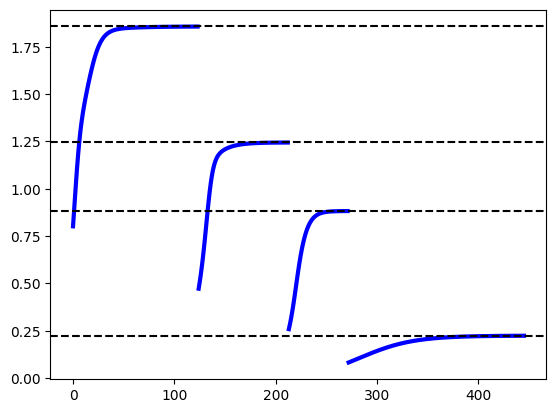

In [ ]:
colors = ['blue', 'orange', 'green', 'purple']

plt.plot([i for i in range(steps_vec[0])], costs_vec[0], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[0], linestyle='--', color='black')
plt.plot([i for i in range(steps_vec[0], steps_vec[0] + steps_vec[1])], costs_vec[1], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[1], linestyle='--', color='black')
plt.plot([i for i in range(steps_vec[0] + steps_vec[1], steps_vec[0] + steps_vec[1] + steps_vec[2])], costs_vec[2], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[2], linestyle='--', color='black')
plt.plot([i for i in range(steps_vec[0] + steps_vec[1] + steps_vec[2], steps_vec[0] + steps_vec[1] + steps_vec[2] + steps_vec[3])], costs_vec[3], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[3], linestyle='--', color='black');

## QuantumGame 10k shots experiment

We perform the experiments for a shot-based simulation of QuantumGame over 10k shots.

In [ ]:
import warnings
from numpy.exceptions import ComplexWarning
warnings.filterwarnings("ignore", category=ComplexWarning)
from functools import partial

def quantum_eigengame(pauli_gates, pauli_gatesh, coeffs, dim, n_eigs=1, tol=1e-5, dev_name='default.qubit', optimizer=qml.AdagradOptimizer(stepsize=0.2), max_steps=100, layers=6, params_layer=5, shots=None):
  assert n_eigs <= dim, "n_eigs greater than the maximum number of eigenvalues"

  qubits = int(numpy.ceil(np.log2(dim)))
  wires = [i for i in range(qubits)]
  dev = qml.device(dev_name, wires=wires, shots=shots)

  qubitsh = qubits + 1
  wiresh = [i for i in range(qubitsh)]
  devh = qml.device(dev_name, wires=wiresh, shots=shots)

  def ansatz(params):
    qml.RandomLayers(params, wires=wires)

  def circuit_vqe(params):
      for w in wires:
        qml.Hadamard(wires=w)
      ansatz(params)

  @qml.compile
  @qml.qnode(dev)
  def cost_function_vqe(params, M):
      circuit_vqe(params)
      return qml.expval(M)
      #return qml.expval(qml.Hermitian(M, wires=wires))

  @qml.compile
  @qml.qnode(devh)
  def hadamard_test_real(params_a, params_b, pauli):

    # Layer for initial state
    for i in range(1, qubitsh):
      qml.Hadamard(i)

    # Hadamard test
    qml.Hadamard(0)
    qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))
    qml.ControlledQubitUnitary(qml.adjoint(qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))), 0)
    qml.ControlledQubitUnitary(qml.RandomLayers(weights=params_b, wires=range(1, qubitsh)), 0)
    qml.Hadamard(0)

    return qml.expval(qml.Z(0) @ pauli)
    #return qml.expval(qml.Hermitian(numpy.kron(Z, pauli), wires=range(qubitsh)))

  @qml.compile
  @qml.qnode(devh)
  def hadamard_test_imag(params_a, params_b, pauli):

    # Layer for initial state
    for i in range(1, qubitsh):
      qml.Hadamard(i)

    # Hadamard test
    qml.Hadamard(0)
    qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))
    qml.ControlledQubitUnitary(qml.adjoint(qml.RandomLayers(weights=params_a, wires=range(1, qubitsh))), 0)
    qml.ControlledQubitUnitary(qml.RandomLayers(weights=params_b, wires=range(1, qubitsh)), 0)
    qml.S(0)
    qml.Hadamard(0)

    return qml.expval(qml.Z(0) @ pauli)
    #return qml.expval(qml.Hermitian(numpy.kron(Z, pauli), wires=range(qubitsh)))

  def hadamard_test(params_a, params_b, pauli):
    return hadamard_test_real(params_a, params_b, pauli) + 1j*hadamard_test_imag(params_a, params_b, pauli)

  def hadamard_test_sum(params, paulis, coeffs, j):
    pauli_combination = -paulis[0]*coeffs[0]
    for i in range(1, len(coeffs)):
        pauli_combination -= paulis[i]*coeffs[i]
    res = hadamard_test(params, params_vec[j], pauli_combination)
    return res

  def cost_function_vqe_sum(params, paulis, coeffs):
    pauli_combination = -paulis[0]*coeffs[0]
    for i in range(1, len(coeffs)):
      pauli_combination -= paulis[i]*coeffs[i]
    res = cost_function_vqe(params, pauli_combination)
    return res

  def cost_function_sum(params, paulis, paulish, coeffs):
    sum = cost_function_vqe_sum(params, paulis=paulis, coeffs=coeffs)
    for j in range(k):
      sum -= np.abs(hadamard_test_sum(params, paulish, coeffs, j))**2/eigenvalues[j]
    return sum

  k=0
  params_vec = []
  eigenvalues = []

  params = np.random.rand(layers, params_layer)

  costs_vec = []
  costs = []
  steps = []
  penalties = 0
  pbar = tqdm(range(max_steps))
  for i in pbar:
      #grad, cost = optimizer.compute_grad(cost_function_vqe_sum, params, paulis=pauli_gates, coeffs=coeffs)
      #params = optimizer.apply_grad(grad, params)
      params, cost = optimizer.step_and_cost(cost_function_vqe_sum, params, paulis=pauli_gates, coeffs=coeffs)
      grad = qml.grad(cost_function_vqe_sum)(params, paulis=pauli_gates, coeffs=coeffs)
      costs.append(-cost)
      rewards = cost
      pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
      if i > 1 and np.linalg.norm(grad) <= tol:
        steps.append(i+1)
        break
  if np.linalg.norm(grad) > tol:
      steps.append(max_steps)
  eigenvalues.append(cost)
  params_vec.append(params)
  costs_vec.append(costs)

  k += 1

  while k < n_eigs:
    params = np.random.rand(layers, params_layer)

    costs = []
    pbar = tqdm(range(max_steps))
    for i in pbar:
        #grad, cost = optimizer.compute_grad(cost_function_sum, params, paulis=pauli_gates, paulish=pauli_gatesh, coeffs=coeffs)
        #params = optimizer.apply_grad(grad, params)
        params, cost = optimizer.step_and_cost(cost_function_sum, params, paulis=pauli_gates, paulish=pauli_gatesh, coeffs=coeffs)
        grad = qml.grad(cost_function_sum)(params, paulis=pauli_gates, paulish=pauli_gatesh, coeffs=coeffs)
        costs.append(-cost)
        rewards = cost_function_vqe_sum(params, pauli_gates, coeffs)
        penalties = cost - rewards
        pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
        if i > 1 and np.linalg.norm(grad) <= tol:
          steps.append(i+1)
          break
    if np.linalg.norm(grad) > tol:
      steps.append(max_steps)

    eigenvalues.append(cost)
    params_vec.append(params)
    costs_vec.append(costs)
    k += 1

  return eigenvalues, params_vec, costs_vec, steps

eigenvalues_10k, params_vec_10k, costs_vec_10k, steps_vec_10k = quantum_eigengame(pauli_gates, pauli_gatesh, coeffs, dim, n_eigs=4, tol=1e-2, dev_name='lightning.qubit', optimizer=qml.GradientDescentOptimizer(stepsize=alpha), max_steps=500, layers=3, params_layer=3, shots=10000)

Iteration 88, Cost: 1.8586, Rewards: 1.8586, Penalties: 0.0000, Gradient norm: 0.0097:  17%|█▋        | 87/500 [00:18<01:27,  4.72it/s]
Iteration 124, Cost: 1.2440, Rewards: 1.2446, Penalties: -0.0006, Gradient norm: 0.0097:  25%|██▍       | 123/500 [06:46<20:45,  3.30s/it]
Iteration 91, Cost: 0.8824, Rewards: 0.8828, Penalties: -0.0004, Gradient norm: 0.0100:  18%|█▊        | 90/500 [09:28<43:09,  6.31s/it]
Iteration 224, Cost: 0.2237, Rewards: 0.2269, Penalties: -0.0032, Gradient norm: 0.0093:  45%|████▍     | 223/500 [34:28<42:48,  9.27s/it]


In [ ]:
data = {
    'eigenvalues_10k': eigenvalues_10k,
    'params_vec_10k': params_vec_10k,
    'costs_vec_10k': costs_vec_10k,
    'steps_vec_10k': steps_vec_10k
}
file = open(current_dir + 'quantumgame_10k.pkl', 'wb')
pickle.dump(data, file)
file.close()

In [ ]:
file = open(current_dir + 'quantumgame_10k.pkl', 'rb')
data = pickle.load(file)
file.close()

eigenvalues_10k = data['eigenvalues_10k']
params_vec_10k = data['params_vec_10k']
costs_vec_10k = data['costs_vec_10k']
steps_vec_10k = data['steps_vec_10k']

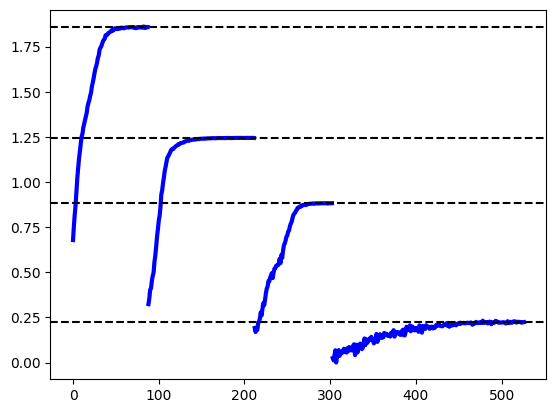

In [ ]:
colors = ['blue', 'orange', 'green', 'purple']

plt.plot([i for i in range(steps_vec_10k[0])], costs_vec_10k[0], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[0], linestyle='--', color='black')
plt.plot([i for i in range(steps_vec_10k[0], steps_vec_10k[0] + steps_vec_10k[1])], costs_vec_10k[1], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[1], linestyle='--', color='black')
plt.plot([i for i in range(steps_vec_10k[0] + steps_vec_10k[1], steps_vec_10k[0] + steps_vec_10k[1] + steps_vec_10k[2])], costs_vec_10k[2], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[2], linestyle='--', color='black')
plt.plot([i for i in range(steps_vec_10k[0] + steps_vec_10k[1] + steps_vec_10k[2], steps_vec_10k[0] + steps_vec_10k[1] + steps_vec_10k[2] + steps_vec_10k[3])], costs_vec_10k[3], color=colors[0], linewidth=3)
plt.axhline(exact_eigvals[3], linestyle='--', color='black');

## VQD noiseless experiment

Here we set the functions and perform the experiments for a noiseless exact statevector simulation of VQD.

In [ ]:
import warnings
from numpy.exceptions import ComplexWarning
warnings.filterwarnings("ignore", category=ComplexWarning)

def vqd(pauli_gates, coeffs, dim, n_eigs=1, tol=1e-5, dev_name='default.qubit', optimizer=qml.AdagradOptimizer(stepsize=0.2), max_steps=100, layers=3, params_layer=3, shots=None):
  assert n_eigs <= dim, "n_eigs greater than the maximum number of eigenvalues"

  qubits = int(numpy.ceil(np.log2(dim)))
  wires = [i for i in range(qubits)]
  dev = qml.device(dev_name, wires, shots=shots)

  qubitsh = 2*qubits + 1
  wiresh = [i for i in range(qubitsh)]
  devh = qml.device('default.qubit', wires=wiresh, shots=shots)

  def ansatz(params, wires):
    qml.RandomLayers(params, wires=wires)

  def circuit_vqe(params, wires):
      for w in wires:
        qml.Hadamard(wires=w)
      ansatz(params, wires)

  @qml.compile
  @qml.qnode(devh, diff_method="adjoint")
  def swap_test(params_a, params_b):
      circuit_vqe(params_a, range(1, qubits + 1))
      circuit_vqe(params_b, range(qubits + 1, 2 * qubits + 1))

      qml.Barrier()  # added to better visualise the circuit
      qml.Hadamard(wires=0)
      for i in range(qubits):
          qml.CSWAP(wires=[0, 1 + i + qubits, 1 + i])
      qml.Hadamard(wires=0)
      return qml.expval(qml.Z(0))

  @qml.compile
  @qml.qnode(dev, diff_method="adjoint")
  def cost_function_vqe(params, M):
      circuit_vqe(params, range(qubits))
      return qml.expval(M)
      #return qml.expval(qml.Hermitian(M, wires=wires))

  def cost_function_vqe_sum(params, paulis, coeffs):
      pauli_combination = -paulis[0]*coeffs[0]
      for i in range(1, len(coeffs)):
        pauli_combination -= paulis[i]*coeffs[i]
      res = cost_function_vqe(params, pauli_combination)
      return res

  #def cost_function_vqe_sum(params, paulis, coeffs):
  #    res = 0
  #    for i in range(len(coeffs)):
  #      res += cost_function_vqe(params, -paulis[i])*(coeffs[i])
  #    return res

  def loss_f(params, betas, paulis, coeffs):
      utility = cost_function_vqe_sum(params, paulis=paulis, coeffs=coeffs)
      for j in range(k):
        utility += betas[j] * swap_test(params_vec[j], params)
      return utility

  k=0
  params_vec = []
  eigenvalues = []

  beta = 0.8
  params = np.random.rand(layers, params_layer)

  costs_vec = []
  costs = []
  steps = []
  betas = [beta]*n_eigs
  penalties = 0
  pbar = tqdm(range(max_steps))
  for i in pbar:
      params, cost = optimizer.step_and_cost(loss_f, params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
      grad = qml.grad(loss_f)(params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
      costs.append(-cost)
      rewards = cost
      pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
      if i > 1 and np.linalg.norm(grad) <= tol:
        steps.append(i+1)
        break
  if np.linalg.norm(grad) > tol:
    steps.append(max_steps)

  eigenvalues.append(cost)
  params_vec.append(params)
  costs_vec.append(costs)

  k += 1

  while k < n_eigs:
    params = np.random.rand(layers, params_layer)

    costs = []
    pbar = tqdm(range(max_steps))
    for i in pbar:
        params, cost = optimizer.step_and_cost(loss_f, params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
        grad = qml.grad(loss_f)(params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
        costs.append(-cost)
        rewards = cost_function_vqe_sum(params, pauli_gates, coeffs)
        penalties = cost - rewards
        pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
        if i > 1 and np.linalg.norm(grad) <= tol:
          steps.append(i+1)
          break
    if np.linalg.norm(grad) > tol:
      steps.append(max_steps)

    eigenvalues.append(cost)
    params_vec.append(params)
    costs_vec.append(costs)
    k += 1

  return eigenvalues, params_vec, costs_vec, steps

qubits = 2
dim = 2**qubits
#pauli_list, coeffs = generate_pauli_string(qubits, terms=10)
pauli_gates = [pauli_to_gate(pauli_str) for pauli_str in pauli_list]
print(pauli_list)
print(pauli_gates)
matrices = pauli_to_matrices(pauli_list)
matrix = full_matrix(matrices, coeffs)
print(np.linalg.eigvalsh(matrix))

vqd_eigenvalues, vqd_params_vec, vqd_costs_vec, vqd_steps_vec = vqd(pauli_gates, coeffs, dim, n_eigs=4, tol=1e-2, dev_name='lightning.qubit', optimizer=qml.GradientDescentOptimizer(stepsize=alpha), max_steps=500, layers=3, params_layer=3)

['II', 'IZ', 'XX', 'ZI', 'ZZ']
[I(0) @ I(1), I(0) @ Z(1), X(0) @ X(1), Z(0) @ I(1), Z(0) @ Z(1)]
[0.22491125 0.88272215 1.24458455 1.85727503]


Iteration 134, Cost: 1.8568, Rewards: 1.8568, Penalties: 0.0000, Gradient norm: 0.0099:  27%|██▋       | 133/500 [00:03<00:08, 43.50it/s]
Iteration 67, Cost: 1.2443, Rewards: 1.2447, Penalties: -0.0004, Gradient norm: 0.0098:  13%|█▎        | 66/500 [00:09<01:01,  7.00it/s]
Iteration 213, Cost: 1.0572, Rewards: 1.8532, Penalties: -0.7960, Gradient norm: 0.0099:  42%|████▏     | 212/500 [00:45<01:01,  4.69it/s]
Iteration 77, Cost: 0.8814, Rewards: 0.8828, Penalties: -0.0014, Gradient norm: 0.0099:  15%|█▌        | 76/500 [00:22<02:02,  3.45it/s]


In [ ]:
data = {
    'vqd_eigenvalues': vqd_eigenvalues,
    'vqd_params_vec': vqd_params_vec,
    'vqd_costs_vec': vqd_costs_vec,
    'vqd_steps_vec': vqd_steps_vec
}
file = open(current_dir + 'vqd_noiseless.pkl', 'wb')
pickle.dump(data, file)
file.close()

In [ ]:
file = open(current_dir + 'vqd_noiseless.pkl', 'rb')
data = pickle.load(file)
file.close()

vqd_eigenvalues = data['vqd_eigenvalues']
vqd_params_vec = data['vqd_params_vec']
vqd_costs_vec = data['vqd_costs_vec']
vqd_steps_vec = data['vqd_steps_vec']

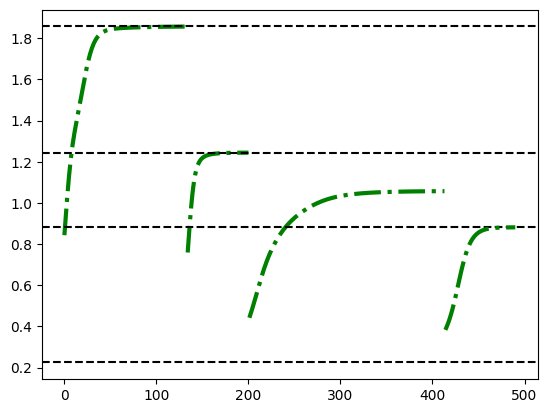

In [ ]:
plt.plot([i for i in range(vqd_steps_vec[0])], vqd_costs_vec[0], color=colors[2], linestyle='-.', linewidth=3)
plt.axhline(exact_eigvals[0], linestyle='--', color='black')
plt.plot([i for i in range(vqd_steps_vec[0], vqd_steps_vec[0] + vqd_steps_vec[1])], vqd_costs_vec[1], color=colors[2], linestyle='-.', linewidth=3)
plt.axhline(exact_eigvals[1], linestyle='--', color='black')
plt.plot([i for i in range(vqd_steps_vec[0] + vqd_steps_vec[1], vqd_steps_vec[0] + vqd_steps_vec[1] + vqd_steps_vec[2])], vqd_costs_vec[2], color=colors[2], linestyle='-.', linewidth=3)
plt.axhline(exact_eigvals[2], linestyle='--', color='black')
plt.plot([i for i in range(vqd_steps_vec[0] + vqd_steps_vec[1] + vqd_steps_vec[2], vqd_steps_vec[0] + vqd_steps_vec[1] + vqd_steps_vec[2] + vqd_steps_vec[3])], vqd_costs_vec[3], color=colors[2], linestyle='-.', linewidth=3)
plt.axhline(exact_eigvals[3], linestyle='--', color='black');

## VQD 10k shots experiment

We perform the experiments for a shot-based simulation of VQD over 10k shots.

In [ ]:
import warnings
from numpy.exceptions import ComplexWarning
warnings.filterwarnings("ignore", category=ComplexWarning)

def vqd(pauli_gates, coeffs, dim, n_eigs=1, tol=1e-5, dev_name='default.qubit', optimizer=qml.AdagradOptimizer(stepsize=0.2), max_steps=100, layers=6, params_layer=5, shots=10000):
  assert n_eigs <= dim, "n_eigs greater than the maximum number of eigenvalues"

  qubits = int(numpy.ceil(np.log2(dim)))
  wires = [i for i in range(qubits)]
  dev = qml.device(dev_name, wires=wires, shots=shots)

  qubitsh = 2*qubits + 1
  wiresh = [i for i in range(qubitsh)]
  devh = qml.device(dev_name, wires=wiresh, shots=shots)

  def ansatz(params, wires):
    qml.RandomLayers(params, wires=wires)

  def circuit_vqe(params, wires):
      for w in wires:
        qml.Hadamard(wires=w)
      ansatz(params, wires)

  @qml.compile
  @qml.qnode(devh)
  def swap_test(params_a, params_b):
      circuit_vqe(params_a, range(1, qubits + 1))
      circuit_vqe(params_b, range(qubits + 1, 2 * qubits + 1))

      qml.Barrier()  # added to better visualise the circuit
      qml.Hadamard(wires=0)
      for i in range(qubits):
          qml.CSWAP(wires=[0, 1 + i + qubits, 1 + i])
      qml.Hadamard(wires=0)
      return qml.expval(qml.Z(0))

  @qml.compile
  @qml.qnode(dev)
  def cost_function_vqe(params, M):
      circuit_vqe(params, range(qubits))
      return qml.expval(M)
      #return qml.expval(qml.Hermitian(M, wires=wires))

  def cost_function_vqe_sum(params, paulis, coeffs):
      pauli_combination = -paulis[0]*coeffs[0]
      for i in range(1, len(coeffs)):
        pauli_combination -= paulis[i]*coeffs[i]
      res = cost_function_vqe(params, pauli_combination)
      return res

  #def cost_function_vqe_sum(params, paulis, coeffs):
  #    res = 0
  #    for i in range(len(coeffs)):
  #      res += cost_function_vqe(params, -paulis[i])*(coeffs[i])
  #    return res

  def loss_f(params, betas, paulis, coeffs):
      utility = cost_function_vqe_sum(params, paulis=paulis, coeffs=coeffs)
      for j in range(k):
        utility += betas[j] * swap_test(params_vec[j], params)
      return utility

  k=0
  params_vec = []
  eigenvalues = []

  beta = 0.8
  params = np.random.rand(layers, params_layer)

  costs_vec = []
  costs = []
  steps = []
  betas = [beta]*n_eigs
  penalties = 0
  pbar = tqdm(range(max_steps))
  for i in pbar:
      params, cost = optimizer.step_and_cost(loss_f, params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
      grad = qml.grad(loss_f)(params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
      costs.append(-cost)
      rewards = cost
      pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
      if i > 1 and np.linalg.norm(grad) <= tol:
          steps.append(i+1)
          break
  if np.linalg.norm(grad) > tol:
      steps.append(max_steps)
  eigenvalues.append(cost)
  params_vec.append(params)
  costs_vec.append(costs)

  k += 1

  while k < n_eigs:
    params = np.random.rand(layers, params_layer)

    costs = []
    pbar = tqdm(range(max_steps))
    for i in pbar:
        params, cost = optimizer.step_and_cost(loss_f, params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
        grad = qml.grad(loss_f)(params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
        costs.append(-cost)
        rewards = cost_function_vqe_sum(params, pauli_gates, coeffs)
        penalties = cost - rewards
        pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
        if i > 1 and np.linalg.norm(grad) <= tol:
          steps.append(i+1)
          break
    if np.linalg.norm(grad) > tol:
      steps.append(max_steps)

    eigenvalues.append(cost)
    params_vec.append(params)
    costs_vec.append(costs)
    k += 1

  return eigenvalues, params_vec, costs_vec, steps

vqd_eigenvalues_10k, vqd_params_vec_10k, vqd_costs_vec_10k, vqd_steps_vec_10k = vqd(pauli_gates, coeffs, dim, n_eigs=4, tol=1e-2, dev_name='lightning.qubit', optimizer=qml.GradientDescentOptimizer(stepsize=alpha), max_steps=500, layers=3, params_layer=3, shots=10000)

Iteration 77, Cost: 1.8629, Rewards: 1.8629, Penalties: 0.0000, Gradient norm: 0.0093:  15%|█▌        | 76/500 [00:16<01:32,  4.58it/s]
Iteration 167, Cost: 1.2479, Rewards: 1.2445, Penalties: 0.0035, Gradient norm: 0.0096:  33%|███▎      | 166/500 [01:03<02:08,  2.60it/s]
Iteration 128, Cost: 1.0589, Rewards: 1.8599, Penalties: -0.8010, Gradient norm: 0.0099:  25%|██▌       | 127/500 [01:09<03:24,  1.82it/s]
Iteration 418, Cost: 0.8826, Rewards: 0.8866, Penalties: -0.0039, Gradient norm: 0.0085:  83%|████████▎ | 417/500 [04:51<00:57,  1.43it/s]


In [ ]:
data = {
    'vqd_eigenvalues_10k': vqd_eigenvalues_10k,
    'vqd_params_vec_10k': vqd_params_vec_10k,
    'vqd_costs_vec_10k': vqd_costs_vec_10k,
    'vqd_steps_vec_10k': vqd_steps_vec_10k
}
file = open(current_dir + 'vqd_10k.pkl', 'wb')
pickle.dump(data, file)
file.close()

In [ ]:
file = open(current_dir + 'vqd_10k.pkl', 'rb')
data = pickle.load(file)
file.close()

vqd_eigenvalues_10k = data['vqd_eigenvalues_10k']
vqd_params_vec_10k = data['vqd_params_vec_10k']
vqd_costs_vec_10k = data['vqd_costs_vec_10k']
vqd_steps_vec_10k = data['vqd_steps_vec_10k']

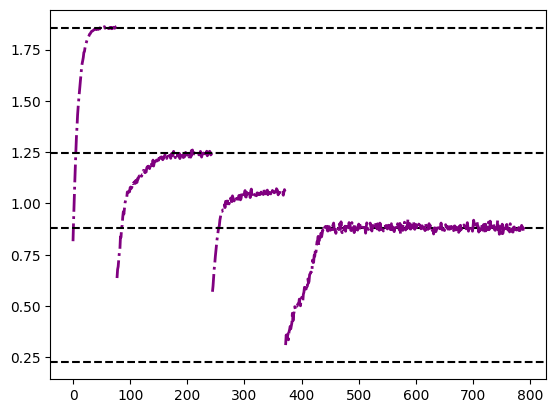

In [ ]:
plt.plot([i for i in range(vqd_steps_vec_10k[0])], vqd_costs_vec_10k[0], color=colors[3], linestyle='-.', linewidth=2)
plt.axhline(exact_eigvals[0], linestyle='--', color='black')
plt.plot([i for i in range(vqd_steps_vec_10k[0], vqd_steps_vec_10k[0] + vqd_steps_vec_10k[1])], vqd_costs_vec_10k[1], color=colors[3], linestyle='-.', linewidth=2)
plt.axhline(exact_eigvals[1], linestyle='--', color='black')
plt.plot([i for i in range(vqd_steps_vec_10k[0] + vqd_steps_vec_10k[1], vqd_steps_vec_10k[0] + vqd_steps_vec_10k[1] + vqd_steps_vec_10k[2])], vqd_costs_vec_10k[2], color=colors[3], linestyle='-.', linewidth=2)
plt.axhline(exact_eigvals[2], linestyle='--', color='black')
plt.plot([i for i in range(vqd_steps_vec_10k[0] + vqd_steps_vec_10k[1] + vqd_steps_vec_10k[2], vqd_steps_vec_10k[0] + vqd_steps_vec_10k[1] + vqd_steps_vec_10k[2] + vqd_steps_vec_10k[3])], vqd_costs_vec_10k[3], color=colors[3], linestyle='-.', linewidth=2)
plt.axhline(exact_eigvals[3], linestyle='--', color='black');

## Recover data

We recover the data previously stored in pickle files.

In [ ]:
file = open(current_dir + 'exact.pkl', 'rb')
data = pickle.load(file)
file.close()

exact_eigvals = data['exact_eigvals']

file = open(current_dir + 'quantumgame_noiseless.pkl', 'rb')
data = pickle.load(file)
file.close()

eigenvalues = data['eigenvalues']
params_vec = data['params_vec']
costs_vec = data['costs_vec']
steps_vec = data['steps_vec']

file = open(current_dir + 'quantumgame_10k.pkl', 'rb')
data = pickle.load(file)
file.close()

eigenvalues_10k = data['eigenvalues_10k']
params_vec_10k = data['params_vec_10k']
costs_vec_10k = data['costs_vec_10k']
steps_vec_10k = data['steps_vec_10k']

file = open(current_dir + 'vqd_noiseless.pkl', 'rb')
data = pickle.load(file)
file.close()

vqd_eigenvalues = data['vqd_eigenvalues']
vqd_params_vec = data['vqd_params_vec']
vqd_costs_vec = data['vqd_costs_vec']
vqd_steps_vec = data['vqd_steps_vec']

file = open(current_dir + 'vqd_10k.pkl', 'rb')
data = pickle.load(file)
file.close()

vqd_eigenvalues_10k = data['vqd_eigenvalues_10k']
vqd_params_vec_10k = data['vqd_params_vec_10k']
vqd_costs_vec_10k = data['vqd_costs_vec_10k']
vqd_steps_vec_10k = data['vqd_steps_vec_10k']

## Plots

Here we show the main quantum results for the QuantumGame paper

In [ ]:
import shutil

# Move the uploaded font file to the system fonts directory
shutil.move('Palatino.ttf', '/usr/share/fonts/truetype/Palatino.ttf')

font_cache_path = os.path.expanduser('~/.cache/matplotlib')
shutil.rmtree(font_cache_path, ignore_errors=True)

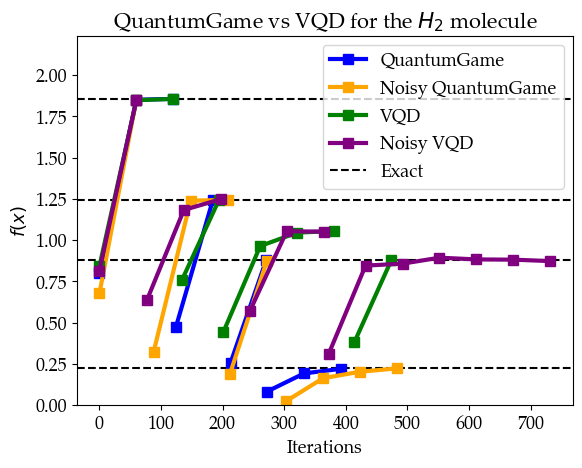

In [ ]:
colors = ['blue', 'orange', 'green', 'purple']
granularity = 60
markers = ['s', 's', 's', 's']
markersize = 7.5
linewidth = 3

def range_func(vec, granularity):
  if len(vec)>=granularity:
    new_vec = vec[::granularity]
    #new_vec = vec[len(vec)::-granularity][::-1]
  else:
    new_vec = [vec[0], vec[-1]]

  return new_vec

costs_vec_granular = [range_func(costs_vec[i], granularity) for i in range(len(costs_vec))]
costs_vec_10k_granular = [range_func(costs_vec_10k[i], granularity) for i in range(len(costs_vec))]
vqd_costs_vec_granular = [range_func(vqd_costs_vec[i], granularity) for i in range(len(costs_vec))]
vqd_costs_vec_10k_granular = [range_func(vqd_costs_vec_10k[i], granularity) for i in range(len(costs_vec))]

plt.rcParams["font.family"] = "Palatino"
plt.rcParams["font.size"] = 13
plt.title(r'QuantumGame vs VQD for the $H_2$ molecule')
plt.xlabel('Iterations')
plt.ylabel(r'$f(x)$')

plt.plot([], linestyle='-', label='QuantumGame', color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot([], linestyle='-', label='Noisy QuantumGame', color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot([], linestyle='-', label='VQD', color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot([], linestyle='-', label='Noisy VQD', color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)
plt.plot([], linestyle='--', label='Exact', color='black')

plt.axhline(exact_eigvals[0], linestyle='--', color='black')
plt.axhline(exact_eigvals[1], linestyle='--', color='black')
plt.axhline(exact_eigvals[2], linestyle='--', color='black')
plt.axhline(exact_eigvals[3], linestyle='--', color='black')

plt.plot(range_func([i for i in range(0, steps_vec[0])], granularity), costs_vec_granular[0], color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot(range_func([i for i in range(0, steps_vec_10k[0])], granularity), costs_vec_10k_granular[0], color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot(range_func([i for i in range(0, vqd_steps_vec[0])], granularity), vqd_costs_vec_granular[0], color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot(range_func([i for i in range(0,vqd_steps_vec_10k[0])], granularity), vqd_costs_vec_10k_granular[0], color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)

plt.plot(range_func([i for i in range(steps_vec[0], sum(steps_vec[:2]))], granularity), costs_vec_granular[1], color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot(range_func([i for i in range(steps_vec_10k[0], sum(steps_vec_10k[:2]))], granularity), costs_vec_10k_granular[1], color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot(range_func([i for i in range(vqd_steps_vec[0], sum(vqd_steps_vec[:2]))], granularity), vqd_costs_vec_granular[1], color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot(range_func([i for i in range(vqd_steps_vec_10k[0], sum(vqd_steps_vec_10k[:2]))], granularity), vqd_costs_vec_10k_granular[1], color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)

plt.plot(range_func([i for i in range(sum(steps_vec[:2]), sum(steps_vec[:3]))], granularity), costs_vec_granular[2], color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot(range_func([i for i in range(sum(steps_vec_10k[:2]), sum(steps_vec_10k[:3]))], granularity), costs_vec_10k_granular[2], color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot(range_func([i for i in range(sum(vqd_steps_vec[:2]), sum(vqd_steps_vec[:3]))], granularity), vqd_costs_vec_granular[2], color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot(range_func([i for i in range(sum(vqd_steps_vec_10k[:2]), sum(vqd_steps_vec_10k[:3]))], granularity), vqd_costs_vec_10k_granular[2], color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)

plt.plot(range_func([i for i in range(sum(steps_vec[:3]), sum(steps_vec[:4]))], granularity), costs_vec_granular[3], color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot(range_func([i for i in range(sum(steps_vec_10k[:3]), sum(steps_vec_10k[:4]))], granularity), costs_vec_10k_granular[3], color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot(range_func([i for i in range(sum(vqd_steps_vec[:3]), sum(vqd_steps_vec[:4]))], granularity), vqd_costs_vec_granular[3], color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot(range_func([i for i in range(sum(vqd_steps_vec_10k[:3]), sum(vqd_steps_vec_10k[:4]))], granularity), vqd_costs_vec_10k_granular[3], color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)
plt.ylim([0, 2.24])
plt.legend();

plt.savefig(current_dir + 'quantumgame_vqd.pdf', bbox_inches='tight')
plt.savefig(current_dir + 'quantumgame_vqd.png', bbox_inches='tight')

# VQD $\beta$ search

## Noiseless

In [ ]:
import warnings
from numpy.exceptions import ComplexWarning
warnings.filterwarnings("ignore", category=ComplexWarning)

def vqd(pauli_gates, coeffs, dim, n_eigs=1, tol=1e-5, dev_name='default.qubit', optimizer=qml.AdagradOptimizer(stepsize=0.2), max_steps=100, layers=3, params_layer=3, shots=None):
  assert n_eigs <= dim, "n_eigs greater than the maximum number of eigenvalues"

  qubits = int(numpy.ceil(np.log2(dim)))
  wires = [i for i in range(qubits)]
  dev = qml.device(dev_name, wires, shots=shots)

  qubitsh = 2*qubits + 1
  wiresh = [i for i in range(qubitsh)]
  devh = qml.device('default.qubit', wires=wiresh, shots=shots)

  def ansatz(params, wires):
    qml.RandomLayers(params, wires=wires)

  def circuit_vqe(params, wires):
      for w in wires:
        qml.Hadamard(wires=w)
      ansatz(params, wires)

  @qml.compile
  @qml.qnode(devh, diff_method="adjoint")
  def swap_test(params_a, params_b):
      circuit_vqe(params_a, range(1, qubits + 1))
      circuit_vqe(params_b, range(qubits + 1, 2 * qubits + 1))

      qml.Barrier()  # added to better visualise the circuit
      qml.Hadamard(wires=0)
      for i in range(qubits):
          qml.CSWAP(wires=[0, 1 + i + qubits, 1 + i])
      qml.Hadamard(wires=0)
      return qml.expval(qml.Z(0))

  @qml.compile
  @qml.qnode(dev, diff_method="adjoint")
  def cost_function_vqe(params, M):
      circuit_vqe(params, range(qubits))
      return qml.expval(M)
      #return qml.expval(qml.Hermitian(M, wires=wires))

  def cost_function_vqe_sum(params, paulis, coeffs):
      pauli_combination = -paulis[0]*coeffs[0]
      for i in range(1, len(coeffs)):
        pauli_combination -= paulis[i]*coeffs[i]
      res = cost_function_vqe(params, pauli_combination)
      return res

  #def cost_function_vqe_sum(params, paulis, coeffs):
  #    res = 0
  #    for i in range(len(coeffs)):
  #      res += cost_function_vqe(params, -paulis[i])*(coeffs[i])
  #    return res

  def loss_f(params, betas, paulis, coeffs):
      utility = cost_function_vqe_sum(params, paulis=paulis, coeffs=coeffs)
      for j in range(k):
        utility += betas[j] * swap_test(params_vec[j], params)
      return utility

  beta_vals = [0.1, 0.5, 1, 2, 3, 4, 5]

  eigenvalues_beta = []
  params_vec_beta = []
  costs_vec_beta = []
  steps_beta = []

  for beta in beta_vals:
    print('Beta:', beta)
    k=0
    params_vec = []
    eigenvalues = []
    params = np.random.rand(layers, params_layer)
    costs_vec = []
    costs = []
    steps = []
    betas = [beta]*n_eigs
    penalties = 0
    pbar = tqdm(range(max_steps))
    for i in pbar:
        params, cost = optimizer.step_and_cost(loss_f, params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
        grad = qml.grad(loss_f)(params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
        costs.append(-cost)
        rewards = cost
        pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
        if i > 1 and np.linalg.norm(grad) <= tol:
          steps.append(i+1)
          break
    if np.linalg.norm(grad) > tol:
      steps.append(max_steps)

    eigenvalues.append(cost)
    params_vec.append(params)
    costs_vec.append(costs)

    k += 1

    while k < n_eigs:
      params = np.random.rand(layers, params_layer)

      costs = []
      pbar = tqdm(range(max_steps))
      for i in pbar:
          params, cost = optimizer.step_and_cost(loss_f, params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
          grad = qml.grad(loss_f)(params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
          costs.append(-cost)
          rewards = cost_function_vqe_sum(params, pauli_gates, coeffs)
          penalties = cost - rewards
          pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
          if i > 1 and np.linalg.norm(grad) <= tol:
            steps.append(i+1)
            break
      if np.linalg.norm(grad) > tol:
        steps.append(max_steps)

      eigenvalues.append(cost)
      params_vec.append(params)
      costs_vec.append(costs)
      k += 1

    eigenvalues_beta.append(eigenvalues)
    params_vec_beta.append(params_vec)
    costs_vec_beta.append(costs_vec)
    steps_beta.append(steps)

  return eigenvalues_beta, params_vec_beta, costs_vec_beta, steps_beta

qubits = 2
dim = 2**qubits
#pauli_list, coeffs = generate_pauli_string(qubits, terms=10)
pauli_gates = [pauli_to_gate(pauli_str) for pauli_str in pauli_list]
print(pauli_list)
print(pauli_gates)
matrices = pauli_to_matrices(pauli_list)
matrix = full_matrix(matrices, coeffs)
print(np.linalg.eigvalsh(matrix))

vqd_eigenvalues_beta, vqd_params_vec_beta, vqd_costs_vec_beta, vqd_steps_vec_beta = vqd(pauli_gates, coeffs, dim, n_eigs=4, tol=1e-2, dev_name='lightning.qubit', optimizer=qml.GradientDescentOptimizer(stepsize=alpha), max_steps=500, layers=3, params_layer=3)

['II', 'IZ', 'XX', 'ZI', 'ZZ']
[I(0) @ I(1), I(0) @ Z(1), X(0) @ X(1), Z(0) @ I(1), Z(0) @ Z(1)]
[0.22491125 0.88272215 1.24458455 1.85727503]
Beta: 0.1


Iteration 67, Cost: 1.8571, Rewards: 1.8571, Penalties: 0.0000, Gradient norm: 0.0097:  13%|█▎        | 66/500 [00:01<00:09, 45.88it/s]
Iteration 97, Cost: 1.7568, Rewards: 1.8567, Penalties: -0.1000, Gradient norm: 0.0099:  19%|█▉        | 96/500 [00:13<00:54,  7.37it/s]
Iteration 75, Cost: 1.6571, Rewards: 1.8571, Penalties: -0.2000, Gradient norm: 0.0098:  15%|█▍        | 74/500 [00:13<01:15,  5.62it/s]
Iteration 78, Cost: 1.2440, Rewards: 1.2445, Penalties: -0.0005, Gradient norm: 0.0098:  15%|█▌        | 77/500 [00:17<01:38,  4.28it/s]


Beta: 0.5


Iteration 145, Cost: 1.8567, Rewards: 1.8567, Penalties: 0.0000, Gradient norm: 0.0100:  29%|██▉       | 144/500 [00:05<00:13, 25.52it/s]
Iteration 211, Cost: 1.3564, Rewards: 1.8513, Penalties: -0.4950, Gradient norm: 0.0100:  42%|████▏     | 210/500 [00:25<00:35,  8.15it/s]
Iteration 64, Cost: 1.2411, Rewards: 1.2446, Penalties: -0.0036, Gradient norm: 0.0097:  13%|█▎        | 63/500 [00:11<01:20,  5.41it/s]
Iteration 203, Cost: 0.8729, Rewards: 1.4337, Penalties: -0.5608, Gradient norm: 0.0100:  40%|████      | 202/500 [00:46<01:09,  4.30it/s]


Beta: 1


...

Iteration 70, Cost: 1.8571, Rewards: 1.8571, Penalties: 0.0000, Gradient norm: 0.0095:  14%|█▍        | 69/500 [00:04<00:26, 16.47it/s]
Iteration 50, Cost: 1.2445, Rewards: 1.2445, Penalties: -0.0000, Gradient norm: 0.0100:  10%|▉         | 49/500 [00:04<00:40, 11.07it/s]
Iteration 55, Cost: 0.8826, Rewards: 0.8827, Penalties: -0.0000, Gradient norm: 0.0096:  11%|█         | 54/500 [00:09<01:21,  5.46it/s]
Iteration 48, Cost: 0.2250, Rewards: 0.2256, Penalties: -0.0005, Gradient norm: 0.0094:   9%|▉         | 47/500 [00:11<01:49,  4.13it/s]


Beta: 4


Iteration 73, Cost: 1.8571, Rewards: 1.8571, Penalties: 0.0000, Gradient norm: 0.0097:  14%|█▍        | 72/500 [00:01<00:09, 47.05it/s]
Iteration 50, Cost: 1.2444, Rewards: 1.2445, Penalties: -0.0000, Gradient norm: 0.0098:  10%|▉         | 49/500 [00:04<00:40, 11.18it/s]
Iteration 57, Cost: 0.8825, Rewards: 0.8826, Penalties: -0.0001, Gradient norm: 0.0095:  11%|█         | 56/500 [00:10<01:21,  5.47it/s]
Iteration 61, Cost: 0.2249, Rewards: 0.2261, Penalties: -0.0012, Gradient norm: 0.0099:  12%|█▏        | 60/500 [00:15<01:55,  3.83it/s]


Beta: 5


Iteration 112, Cost: 1.8568, Rewards: 1.8568, Penalties: 0.0000, Gradient norm: 0.0099:  22%|██▏       | 111/500 [00:02<00:08, 45.97it/s]
Iteration 81, Cost: 1.2443, Rewards: 1.2444, Penalties: -0.0000, Gradient norm: 0.0098:  16%|█▌        | 80/500 [00:09<00:49,  8.57it/s]
Iteration 58, Cost: 0.8804, Rewards: 0.8824, Penalties: -0.0020, Gradient norm: 0.0095:  11%|█▏        | 57/500 [00:10<01:20,  5.49it/s]
Iteration 39, Cost: 0.2257, Rewards: 0.2271, Penalties: -0.0014, Gradient norm: 0.0099:   8%|▊         | 38/500 [00:09<01:54,  4.04it/s]


In [ ]:
beta_vals = [0.1, 0.5, 1, 2, 3, 4, 5]

data = {
    'beta_vals': beta_vals,
    'vqd_eigenvalues_beta': vqd_eigenvalues_beta,
    'vqd_params_vec_beta': vqd_params_vec_beta,
    'vqd_costs_vec_beta': vqd_costs_vec_beta,
    'vqd_steps_vec_beta': vqd_steps_vec_beta
}
file = open(current_dir + 'vqd_noiseless_beta.pkl', 'wb')
pickle.dump(data, file)
file.close()

NameError: name 'vqd_eigenvalues_beta' is not defined

In [ ]:
file = open(current_dir + 'vqd_noiseless_beta.pkl', 'rb')
data = pickle.load(file)
file.close()

beta_vals = data['beta_vals']
vqd_eigenvalues_beta = data['vqd_eigenvalues_beta']
vqd_params_vec_beta = data['vqd_params_vec_beta']
vqd_costs_vec_beta = data['vqd_costs_vec_beta']
vqd_steps_vec_beta = data['vqd_steps_vec_beta']

<BarContainer object of 7 artists>

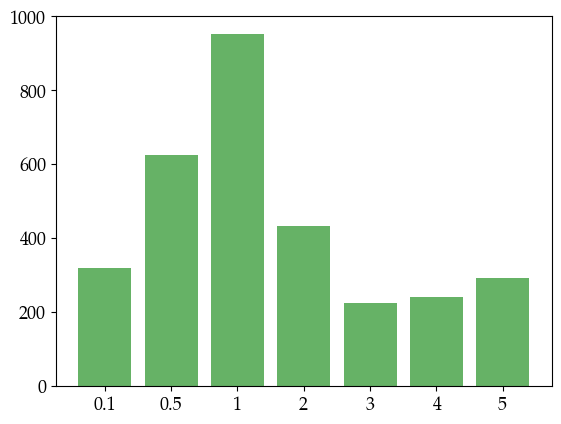

In [ ]:
total_steps_beta = np.array(vqd_steps_vec_beta).sum(axis=1)
plt.bar([str(beta_vals[i]) for i in range(len(beta_vals))], total_steps_beta, color='green', alpha=0.6)

## VQD 10k shots

In [ ]:
import warnings
from numpy.exceptions import ComplexWarning
warnings.filterwarnings("ignore", category=ComplexWarning)

def vqd(pauli_gates, coeffs, dim, n_eigs=1, tol=1e-5, dev_name='default.qubit', optimizer=qml.AdagradOptimizer(stepsize=0.2), max_steps=100, layers=6, params_layer=5, shots=10000):
  assert n_eigs <= dim, "n_eigs greater than the maximum number of eigenvalues"

  qubits = int(numpy.ceil(np.log2(dim)))
  wires = [i for i in range(qubits)]
  dev = qml.device(dev_name, wires=wires, shots=shots)

  qubitsh = 2*qubits + 1
  wiresh = [i for i in range(qubitsh)]
  devh = qml.device(dev_name, wires=wiresh, shots=shots)

  def ansatz(params, wires):
    qml.RandomLayers(params, wires=wires)

  def circuit_vqe(params, wires):
      for w in wires:
        qml.Hadamard(wires=w)
      ansatz(params, wires)

  @qml.compile
  @qml.qnode(devh)
  def swap_test(params_a, params_b):
      circuit_vqe(params_a, range(1, qubits + 1))
      circuit_vqe(params_b, range(qubits + 1, 2 * qubits + 1))

      qml.Barrier()  # added to better visualise the circuit
      qml.Hadamard(wires=0)
      for i in range(qubits):
          qml.CSWAP(wires=[0, 1 + i + qubits, 1 + i])
      qml.Hadamard(wires=0)
      return qml.expval(qml.Z(0))

  @qml.compile
  @qml.qnode(dev)
  def cost_function_vqe(params, M):
      circuit_vqe(params, range(qubits))
      return qml.expval(M)
      #return qml.expval(qml.Hermitian(M, wires=wires))

  def cost_function_vqe_sum(params, paulis, coeffs):
      pauli_combination = -paulis[0]*coeffs[0]
      for i in range(1, len(coeffs)):
        pauli_combination -= paulis[i]*coeffs[i]
      res = cost_function_vqe(params, pauli_combination)
      return res

  #def cost_function_vqe_sum(params, paulis, coeffs):
  #    res = 0
  #    for i in range(len(coeffs)):
  #      res += cost_function_vqe(params, -paulis[i])*(coeffs[i])
  #    return res

  def loss_f(params, betas, paulis, coeffs):
      utility = cost_function_vqe_sum(params, paulis=paulis, coeffs=coeffs)
      for j in range(k):
        utility += betas[j] * swap_test(params_vec[j], params)
      return utility

  beta_vals = [0.1, 0.5, 1, 2, 3, 4, 5]

  eigenvalues_beta = []
  params_vec_beta = []
  costs_vec_beta = []
  steps_beta = []

  for beta in beta_vals:
    print('Beta:', beta)

    k=0
    params_vec = []
    eigenvalues = []

    params = np.random.rand(layers, params_layer)

    costs_vec = []
    costs = []
    steps = []
    betas = [beta]*n_eigs
    penalties = 0
    pbar = tqdm(range(max_steps))
    for i in pbar:
        params, cost = optimizer.step_and_cost(loss_f, params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
        grad = qml.grad(loss_f)(params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
        costs.append(-cost)
        rewards = cost
        pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
        if i > 1 and np.linalg.norm(grad) <= tol:
            steps.append(i+1)
            break
    if np.linalg.norm(grad) > tol:
        steps.append(max_steps)
    eigenvalues.append(cost)
    params_vec.append(params)
    costs_vec.append(costs)

    k += 1

    while k < n_eigs:
      params = np.random.rand(layers, params_layer)

      costs = []
      pbar = tqdm(range(max_steps))
      for i in pbar:
          params, cost = optimizer.step_and_cost(loss_f, params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
          grad = qml.grad(loss_f)(params, betas=betas, paulis=pauli_gates, coeffs=coeffs)
          costs.append(-cost)
          rewards = cost_function_vqe_sum(params, pauli_gates, coeffs)
          penalties = cost - rewards
          pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards:.4f}, Penalties: {-penalties:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
          if i > 1 and np.linalg.norm(grad) <= tol:
            steps.append(i+1)
            break
      if np.linalg.norm(grad) > tol:
        steps.append(max_steps)

      eigenvalues.append(cost)
      params_vec.append(params)
      costs_vec.append(costs)
      k += 1

    eigenvalues_beta.append(eigenvalues)
    params_vec_beta.append(params_vec)
    costs_vec_beta.append(costs_vec)
    steps_beta.append(steps)

  return eigenvalues_beta, params_vec_beta, costs_vec_beta, steps_beta

vqd_eigenvalues_10k_beta, vqd_params_vec_10k_beta, vqd_costs_vec_10k_beta, vqd_steps_vec_10k_beta = vqd(pauli_gates, coeffs, dim, n_eigs=4, tol=1e-2, dev_name='lightning.qubit', optimizer=qml.GradientDescentOptimizer(stepsize=alpha), max_steps=500, layers=3, params_layer=3, shots=10000)

Beta: 0.1


Iteration 140, Cost: 1.8623, Rewards: 1.8623, Penalties: 0.0000, Gradient norm: 0.0080:  28%|██▊       | 139/500 [00:25<01:04,  5.56it/s]
Iteration 80, Cost: 1.7557, Rewards: 1.8557, Penalties: -0.1001, Gradient norm: 0.0091:  16%|█▌        | 79/500 [00:26<02:21,  2.98it/s]
Iteration 140, Cost: 1.6579, Rewards: 1.8554, Penalties: -0.1975, Gradient norm: 0.0085:  28%|██▊       | 139/500 [01:06<02:51,  2.10it/s]
Iteration 137, Cost: 1.5562, Rewards: 1.8554, Penalties: -0.2992, Gradient norm: 0.0095:  27%|██▋       | 136/500 [01:24<03:45,  1.61it/s]


Beta: 0.5


Iteration 86, Cost: 1.8558, Rewards: 1.8558, Penalties: 0.0000, Gradient norm: 0.0099:  17%|█▋        | 85/500 [00:15<01:16,  5.42it/s]
Iteration 231, Cost: 1.3543, Rewards: 1.8548, Penalties: -0.5006, Gradient norm: 0.0098:  46%|████▌     | 230/500 [01:16<01:30,  2.99it/s]
Iteration 85, Cost: 1.2381, Rewards: 1.2451, Penalties: -0.0070, Gradient norm: 0.0097:  17%|█▋        | 84/500 [00:39<03:16,  2.11it/s]
Iteration 102, Cost: 0.8860, Rewards: 0.9462, Penalties: -0.0603, Gradient norm: 0.0081:  20%|██        | 101/500 [01:01<04:03,  1.64it/s]


Beta: 1


...

Iteration 116, Cost: 1.8544, Rewards: 1.8544, Penalties: 0.0000, Gradient norm: 0.0082:  23%|██▎       | 115/500 [00:20<01:08,  5.60it/s]
Iteration 500, Cost: 1.1539, Rewards: 1.2446, Penalties: -0.0907, Gradient norm: 0.0701: 100%|██████████| 500/500 [02:42<00:00,  3.08it/s]
Iteration 500, Cost: 0.8504, Rewards: 0.8826, Penalties: -0.0322, Gradient norm: 0.0959: 100%|██████████| 500/500 [03:51<00:00,  2.16it/s]
Iteration 500, Cost: 0.2427, Rewards: 0.2296, Penalties: 0.0131, Gradient norm: 0.1228: 100%|██████████| 500/500 [04:56<00:00,  1.69it/s]


Beta: 4


Iteration 67, Cost: 1.8571, Rewards: 1.8571, Penalties: 0.0000, Gradient norm: 0.0095:  13%|█▎        | 66/500 [00:11<01:17,  5.61it/s]
Iteration 500, Cost: 1.2818, Rewards: 1.2444, Penalties: 0.0374, Gradient norm: 0.1155: 100%|██████████| 500/500 [02:38<00:00,  3.15it/s]
Iteration 500, Cost: 0.9012, Rewards: 0.8832, Penalties: 0.0181, Gradient norm: 0.1465: 100%|██████████| 500/500 [03:46<00:00,  2.20it/s]
Iteration 500, Cost: 0.1857, Rewards: 0.2262, Penalties: -0.0405, Gradient norm: 0.1001: 100%|██████████| 500/500 [05:00<00:00,  1.67it/s]


Beta: 5


Iteration 82, Cost: 1.8584, Rewards: 1.8584, Penalties: 0.0000, Gradient norm: 0.0093:  16%|█▌        | 81/500 [00:14<01:16,  5.47it/s]
Iteration 500, Cost: 1.2445, Rewards: 1.2446, Penalties: -0.0001, Gradient norm: 0.0897: 100%|██████████| 500/500 [02:38<00:00,  3.16it/s]
Iteration 500, Cost: 0.8407, Rewards: 0.8828, Penalties: -0.0421, Gradient norm: 0.1533: 100%|██████████| 500/500 [03:49<00:00,  2.18it/s]
Iteration 500, Cost: 0.3324, Rewards: 0.2303, Penalties: 0.1021, Gradient norm: 0.2217: 100%|██████████| 500/500 [04:56<00:00,  1.68it/s]


In [ ]:
beta_vals = [0.1, 0.5, 1, 2, 3, 4, 5]

data = {
    'beta_vals': beta_vals,
    'vqd_eigenvalues_10k_beta': vqd_eigenvalues_10k_beta,
    'vqd_params_vec_10k_beta': vqd_params_vec_10k_beta,
    'vqd_costs_vec_10k_beta': vqd_costs_vec_10k_beta,
    'vqd_steps_vec_10k_beta': vqd_steps_vec_10k_beta
}
file = open(current_dir + 'vqd_noiseless_10k_beta.pkl', 'wb')
pickle.dump(data, file)
file.close()

In [ ]:
file = open(current_dir + 'vqd_noiseless_10k_beta.pkl', 'rb')
data = pickle.load(file)
file.close()

beta_vals = data['beta_vals']
vqd_eigenvalues_10k_beta = data['vqd_eigenvalues_10k_beta']
vqd_params_vec_10k_beta = data['vqd_params_vec_10k_beta']
vqd_costs_vec_10k_beta = data['vqd_costs_vec_10k_beta']
vqd_steps_vec_10k_beta = data['vqd_steps_vec_10k_beta']

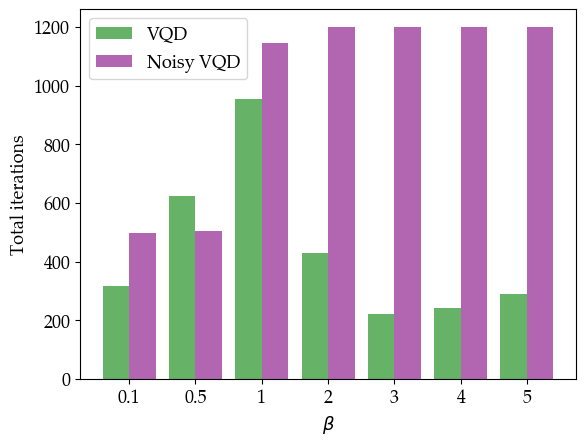

In [ ]:
total_steps_beta = [min(1200, count) for count in np.array(vqd_steps_vec_beta).sum(axis=1)]
total_steps_10k_beta = [min(1200, count) for count in np.array(vqd_steps_vec_10k_beta).sum(axis=1)]
plt.bar([i-0.2 for i in range(len(beta_vals))], total_steps_beta, 0.4, color='green', alpha=0.6, label='VQD')
plt.bar([i+0.2 for i in range(len(beta_vals))], total_steps_10k_beta, 0.4, color='purple', alpha=0.6, label='Noisy VQD')
plt.xticks([i for i in range(len(beta_vals))], [str(beta_val) for beta_val in beta_vals])
plt.xlabel(r'$\beta$')
plt.ylabel('Total iterations')
plt.legend()

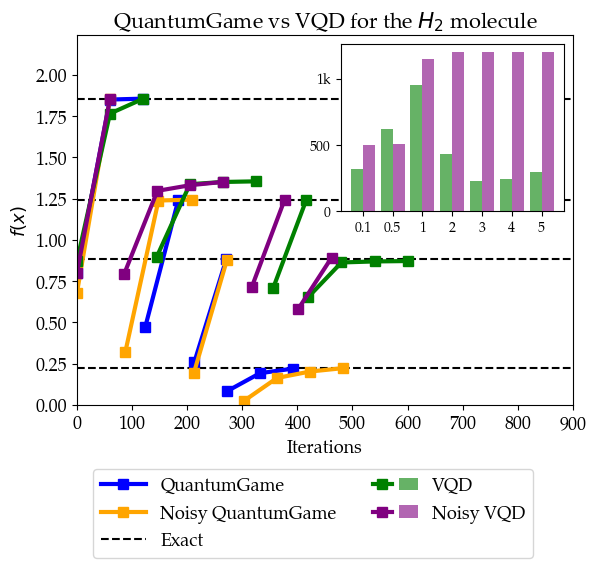

In [ ]:
colors = ['blue', 'orange', 'green', 'purple']
granularity = 60
markers = ['s', 's', 's', 's']
markersize = 7.5
linewidth = 3

def range_func(vec, granularity):
  if len(vec)>=granularity:
    new_vec = vec[::granularity]
    #new_vec = vec[len(vec)::-granularity][::-1]
  else:
    new_vec = [vec[0], vec[-1]]

  return new_vec

vqd_costs_vec = vqd_costs_vec_beta[1]
vqd_costs_vec_10k = vqd_costs_vec_10k_beta[1]
vqd_steps_vec = vqd_steps_vec_beta[1]
vqd_steps_vec_10k = vqd_steps_vec_10k_beta[1]

costs_vec_granular = [range_func(costs_vec[i], granularity) for i in range(len(costs_vec))]
costs_vec_10k_granular = [range_func(costs_vec_10k[i], granularity) for i in range(len(costs_vec))]
vqd_costs_vec_granular = [range_func(vqd_costs_vec[i], granularity) for i in range(len(costs_vec))]
vqd_costs_vec_10k_granular = [range_func(vqd_costs_vec_10k[i], granularity) for i in range(len(costs_vec))]

plt.rcParams["font.family"] = "Palatino"
plt.rcParams["font.size"] = 13
plt.title(r'QuantumGame vs VQD for the $H_2$ molecule')
plt.xlabel('Iterations')
plt.ylabel(r'$f(x)$')

plt.plot([], linestyle='-', label='QuantumGame', color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot([], linestyle='-', label='Noisy QuantumGame', color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot([], linestyle='-', label='VQD', color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot([], linestyle='-', label='Noisy VQD', color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)
plt.plot([], linestyle='--', label='Exact', color='black')

plt.axhline(exact_eigvals[0], linestyle='--', color='black')
plt.axhline(exact_eigvals[1], linestyle='--', color='black')
plt.axhline(exact_eigvals[2], linestyle='--', color='black')
plt.axhline(exact_eigvals[3], linestyle='--', color='black')

plt.plot(range_func([i for i in range(0, steps_vec[0])], granularity), costs_vec_granular[0], color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot(range_func([i for i in range(0, steps_vec_10k[0])], granularity), costs_vec_10k_granular[0], color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot(range_func([i for i in range(0, vqd_steps_vec[0])], granularity), vqd_costs_vec_granular[0], color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot(range_func([i for i in range(0,vqd_steps_vec_10k[0])], granularity), vqd_costs_vec_10k_granular[0], color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)

plt.plot(range_func([i for i in range(steps_vec[0], sum(steps_vec[:2]))], granularity), costs_vec_granular[1], color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot(range_func([i for i in range(steps_vec_10k[0], sum(steps_vec_10k[:2]))], granularity), costs_vec_10k_granular[1], color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot(range_func([i for i in range(vqd_steps_vec[0], sum(vqd_steps_vec[:2]))], granularity), vqd_costs_vec_granular[1], color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot(range_func([i for i in range(vqd_steps_vec_10k[0], sum(vqd_steps_vec_10k[:2]))], granularity), vqd_costs_vec_10k_granular[1], color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)

plt.plot(range_func([i for i in range(sum(steps_vec[:2]), sum(steps_vec[:3]))], granularity), costs_vec_granular[2], color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot(range_func([i for i in range(sum(steps_vec_10k[:2]), sum(steps_vec_10k[:3]))], granularity), costs_vec_10k_granular[2], color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot(range_func([i for i in range(sum(vqd_steps_vec[:2]), sum(vqd_steps_vec[:3]))], granularity), vqd_costs_vec_granular[2], color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot(range_func([i for i in range(sum(vqd_steps_vec_10k[:2]), sum(vqd_steps_vec_10k[:3]))], granularity), vqd_costs_vec_10k_granular[2], color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)

plt.plot(range_func([i for i in range(sum(steps_vec[:3]), sum(steps_vec[:4]))], granularity), costs_vec_granular[3], color=colors[0], linewidth=linewidth, marker=markers[0], markersize=markersize)
plt.plot(range_func([i for i in range(sum(steps_vec_10k[:3]), sum(steps_vec_10k[:4]))], granularity), costs_vec_10k_granular[3], color=colors[1], linewidth=linewidth, marker=markers[1], markersize=markersize)
plt.plot(range_func([i for i in range(sum(vqd_steps_vec[:3]), sum(vqd_steps_vec[:4]))], granularity), vqd_costs_vec_granular[3], color=colors[2], linewidth=linewidth, marker=markers[2], markersize=markersize)
plt.plot(range_func([i for i in range(sum(vqd_steps_vec_10k[:3]), sum(vqd_steps_vec_10k[:4]))], granularity), vqd_costs_vec_10k_granular[3], color=colors[3], linewidth=linewidth, marker=markers[3], markersize=markersize)
plt.ylim([0, 2.24])
plt.xlim([0, 900])

handles, labels = plt.gca().get_legend_handles_labels()

axins = inset_axes(plt.gca(), width="45%", height="45%", loc="upper right", borderpad=0.5)
axins.bar([i-0.2 for i in range(len(beta_vals))], total_steps_beta, 0.4, color='green', alpha=0.6, label='VQD')
axins.bar([i+0.2 for i in range(len(beta_vals))], total_steps_10k_beta, 0.4, color='purple', alpha=0.6, label='Noisy VQD')
axins.set_xticks([i for i in range(len(beta_vals))], [str(beta_val) for beta_val in beta_vals], fontsize=10)
axins.set_yticks([0, 500, 1000], ['0', '500', '1k'], fontsize=10)

handles_ins, labels_ins = axins.get_legend_handles_labels()
order = [0, 1, 4]
order_ins = [0, 1]
plt.legend([handles[idx] for idx in order]+[(handles[2+idx], handles_ins[idx]) for idx in order_ins],
           [labels[idx] for idx in order]+[labels_ins[idx] for idx in order_ins],
           bbox_to_anchor=(0.9, -1.5),
           ncol=2,
           handler_map={
            #Line2D: handler_line1,
            tuple: HandlerTuple(ndivide=None)  # Automatically adjusts based on the tuple of handles
           },
           handlelength=2.5);

plt.savefig(current_dir + 'quantumgame_vqd.pdf', bbox_inches='tight')
plt.savefig(current_dir + 'quantumgame_vqd.png', bbox_inches='tight')